<h1 style="
    text-align:center;
    color: #38BDF8 ;
    font-family: Georgia;
    font-size: 36px;
    font-weight: bold;
">
   AadharLens🫆

<p style="
    text-align: center;
    color: #666;
    font-family: Arial;
    font-size: 10px;
">
    UIDAI DATA ANALYSIS HACKATHON 
</p>

## $Problem$ $Statement$ -

### **From Aadhaar Activity to Action: Detecting Hidden Service Pressure Across India**

Aadhaar activity is not limited to new enrolments. Every day, the system also handles demographic and biometric updates across different age groups and geographies. However, simply measuring the total number of transactions can hide important differences between districts and may overlook locations experiencing unusual or rapidly changing demand.

**Our objective is to use exploratory data analysis (EDA) to uncover these hidden patterns in Aadhaar activity and identify districts where service demand behaves unusually relative to their own historical patterns.**

The study will investigate three key dimensions:

1. **Demand:** Where is Aadhaar enrolment concentrated, and how does it vary across age groups and time?
2. **Maintenance:** Which districts have a high intensity of demographic and biometric updates relative to enrolment?
3. **Anomalies:** Which districts experience unusually high or low Aadhaar activity, and when do these deviations occur?

By combining temporal analysis, demographic composition, maintenance intensity, district-level comparisons, and anomaly detection, we aim to move beyond simple rankings and develop an **EDA-driven district behaviour framework** that can help identify locations requiring closer operational attention.

> **Core Research Question:**
> **“Where is Aadhaar activity behaving differently from the normal pattern, and what does that reveal about potential service pressure across districts?”**

The final outcome will translate these patterns into clear, evidence-based insights and prioritisation categories—not causal claims—while highlighting areas that may warrant further investigation or operational attention.


### Importing IMP libraries -

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
df = pd.read_csv("UIDAI.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (94955, 12)


,Unnamed: 0,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271
1,1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327
2,2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753
3,3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583
4,4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426


--------------------------------------------------------------------------------------------------------------------------------------------

In [6]:
# Removing THE Index Column -

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94955 entries, 0 to 94954
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            94955 non-null  object
 1   state           94955 non-null  object
 2   district        94955 non-null  object
 3   pincode         94955 non-null  int64 
 4   age_0_5         94955 non-null  int64 
 5   age_5_17        94955 non-null  int64 
 6   age_18_greater  94955 non-null  int64 
 7   demo_age_5_17   94955 non-null  int64 
 8   demo_age_17_    94955 non-null  int64 
 9   bio_age_5_17    94955 non-null  int64 
 10  bio_age_17_     94955 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 8.0+ MB


------------------------------------------------------------------------------------------------------------------------------------------

### Data Quality Check -

In [7]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "unique": df.nunique()
})

display(quality_report)

,dtype,missing,missing_%,unique
date,object,0,0.00,23
state,object,0,0.00,46
district,object,0,0.00,880
pincode,int64,0,0.00,17560
age_0_5,int64,0,0.00,270
age_5_17,int64,0,0.00,204
age_18_greater,int64,0,0.00,56
demo_age_5_17,int64,0,0.00,242
demo_age_17_,int64,0,0.00,621
bio_age_5_17,int64,0,0.00,495


-----------------------------------------------------------------------------------------------------------------------------------------

### Date Validation -

In [8]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

print("Invalid dates:", df["date"].isna().sum())

Minimum date: 2025-04-01 00:00:00
Maximum date: 2025-09-19 00:00:00
Invalid dates: 0


---------------------------------------------------------------------------------------------------------------------------------------

### Sates Standerdization -

In [10]:
state_mapping = {
    "Orissa": "Odisha",
    "Westbengal": "West Bengal",
    "andhra pradesh": "Andhra Pradesh",
    "Pondicherry": "Puducherry",
    "Jammu & Kashmir": "Jammu and Kashmir",
    "Andaman & Nicobar Islands": "Andaman and Nicobar Islands",

    "Dadra & Nagar Haveli":
        "Dadra and Nagar Haveli and Daman and Diu",

    "Dadra and Nagar Haveli":
        "Dadra and Nagar Haveli and Daman and Diu",

    "Daman & Diu":
        "Dadra and Nagar Haveli and Daman and Diu",

    "Daman and Diu":
        "Dadra and Nagar Haveli and Daman and Diu"
}

df["state_clean"] = df["state"].replace(state_mapping)

In [11]:
comparison = pd.DataFrame({
    "Before": df["state"].value_counts(),
    "After": df["state_clean"].value_counts()
})

print("Raw state categories:", df["state"].nunique())
print("Clean state categories:", df["state_clean"].nunique())

Raw state categories: 46
Clean state categories: 36


------------------------------------------------------------------------------------------------------------------------------------------------

### Pincode Validation -

In [12]:
df["pincode_str"] = df["pincode"].astype(str)

df["valid_pincode"] = (
    df["pincode_str"]
    .str.fullmatch(r"[1-8]\d{5}")
)

print(
    "Invalid pincodes:",
    (~df["valid_pincode"]).sum()
)

Invalid pincodes: 0


---------------------------------------------------------------------------------------------------------------------------------------

### Finding the Duplicates -

In [14]:
exact_duplicates = df.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

Exact duplicate rows: 2927


In [16]:
key_cols = [
    "date",
    "state_clean",
    "district",
    "pincode"
]

duplicate_count = df.duplicated(
    subset=key_cols,
    keep=False
).sum()

print("Duplicate records:", duplicate_count)

Duplicate records: 5979


In [17]:
duplicate_groups = (
    df.groupby(key_cols)
      .size()
      .reset_index(name="row_count")
)

duplicate_groups = duplicate_groups[
    duplicate_groups["row_count"] > 1
]

display(
    duplicate_groups
    .sort_values("row_count", ascending=False)
    .head(20)
)

,date,state_clean,district,pincode,row_count
8788,2025-09-02,Odisha,Balangir,767020,4
8793,2025-09-02,Odisha,Balangir,767033,3
8897,2025-09-02,Odisha,Ganjam,761118,3
8787,2025-09-02,Odisha,Balangir,767002,3
8830,2025-09-02,Odisha,Bhadrak,756114,3
8826,2025-09-02,Odisha,Bhadrak,756100,3
32795,2025-09-08,Madhya Pradesh,Shahdol,484001,2
32765,2025-09-08,Madhya Pradesh,Satna,485112,2
32770,2025-09-08,Madhya Pradesh,Satna,485446,2
32776,2025-09-08,Madhya Pradesh,Satna,485881,2


### Handeling the Duplicates -

In [18]:
activity_cols = [
    "age_0_5",
    "age_5_17",
    "age_18_greater",
    "demo_age_5_17",
    "demo_age_17_",
    "bio_age_5_17",
    "bio_age_17_"
]

In [19]:
check_cols = key_cols + activity_cols

duplicate_value_check = (
    df.groupby(key_cols)[activity_cols]
      .nunique()
)

display(
    duplicate_value_check
    .max(axis=1)
    .value_counts()
)

1    91896
2       66
Name: count, dtype: int64

In [20]:
df = df.drop_duplicates(
    subset=check_cols,
    keep="first"
)

In [21]:
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu,600045,True,Valid
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,Rajasthan,326038,True,Valid
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,Madhya Pradesh,464551,True,Valid
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,Madhya Pradesh,454001,True,Valid
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,Chandigarh,160036,True,Valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,Delhi,110017,True,Valid
94951,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,Delhi,110081,True,Valid
94952,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,Delhi,110052,True,Valid
94953,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,Delhi,110036,True,Valid


------------------------------------------------------------------------------------------------------------------------------------------

### Feature Engeneering -

In [25]:
df["total_enrolment"] = (
    df["age_0_5"]
    + df["age_5_17"]
    + df["age_18_greater"]
)

df["total_demo_updates"] = (
    df["demo_age_5_17"]
    + df["demo_age_17_"]
)

df["total_bio_updates"] = (
    df["bio_age_5_17"]
    + df["bio_age_17_"]
)

df["total_updates"] = (
    df["total_demo_updates"]
    + df["total_bio_updates"]
)

df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity,total_enrolment,total_demo_updates,total_bio_updates,total_updates,update_to_enrolment_ratio
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu,600045,True,Valid,114,555,464,1019,8.94
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,Rajasthan,326038,True,Valid,173,664,479,1143,6.61
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,Madhya Pradesh,464551,True,Valid,342,1243,2742,3985,11.65
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,Madhya Pradesh,454001,True,Valid,402,2176,3358,5534,13.77
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,Chandigarh,160036,True,Valid,117,1841,968,2809,24.01


#### Maintenance-to-Enrolment Ratio -

In [28]:
df["update_to_enrolment_ratio"] = np.where(
    df["total_enrolment"] > 0,
    df["total_updates"] / df["total_enrolment"],
    np.nan
)

df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity,total_enrolment,total_demo_updates,total_bio_updates,total_updates,update_to_enrolment_ratio
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu,600045,True,Valid,114,555,464,1019,8.94
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,Rajasthan,326038,True,Valid,173,664,479,1143,6.61
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,Madhya Pradesh,464551,True,Valid,342,1243,2742,3985,11.65
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,Madhya Pradesh,454001,True,Valid,402,2176,3358,5534,13.77
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,Chandigarh,160036,True,Valid,117,1841,968,2809,24.01


#### CHILD ENROLMENT SHARE -

In [29]:
df["child_share"] = np.where(
    df["total_enrolment"] > 0,
    df["age_0_5"] / df["total_enrolment"],
    np.nan
)

df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity,total_enrolment,total_demo_updates,total_bio_updates,total_updates,update_to_enrolment_ratio,child_share
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu,600045,True,Valid,114,555,464,1019,8.94,0.71
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,Rajasthan,326038,True,Valid,173,664,479,1143,6.61,0.65
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,Madhya Pradesh,464551,True,Valid,342,1243,2742,3985,11.65,0.85
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,Madhya Pradesh,454001,True,Valid,402,2176,3358,5534,13.77,0.63
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,Chandigarh,160036,True,Valid,117,1841,968,2809,24.01,0.74


#### BIOMETRIC UPDATE SHARE - 

In [30]:
df["bio_update_share"] = np.where(
    df["total_updates"] > 0,
    df["total_bio_updates"] / df["total_updates"],
    np.nan
)

df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity,total_enrolment,total_demo_updates,total_bio_updates,total_updates,update_to_enrolment_ratio,child_share,bio_update_share
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu,600045,True,Valid,114,555,464,1019,8.94,0.71,0.46
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,Rajasthan,326038,True,Valid,173,664,479,1143,6.61,0.65,0.42
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,Madhya Pradesh,464551,True,Valid,342,1243,2742,3985,11.65,0.85,0.69
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,Madhya Pradesh,454001,True,Valid,402,2176,3358,5534,13.77,0.63,0.61
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,Chandigarh,160036,True,Valid,117,1841,968,2809,24.01,0.74,0.34


#### TIME FEATURES -

In [33]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.day_name()
df["day_of_week"] = df["date"].dt.dayofweek

df["is_weekend"] = df["day_of_week"] >= 5
df["week"] = df["date"].dt.isocalendar().week.astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92028 entries, 0 to 94954
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       92028 non-null  datetime64[ns]
 1   state                      92028 non-null  object        
 2   district                   92028 non-null  object        
 3   pincode                    92028 non-null  int64         
 4   age_0_5                    92028 non-null  int64         
 5   age_5_17                   92028 non-null  int64         
 6   age_18_greater             92028 non-null  int64         
 7   demo_age_5_17              92028 non-null  int64         
 8   demo_age_17_               92028 non-null  int64         
 9   bio_age_5_17               92028 non-null  int64         
 10  bio_age_17_                92028 non-null  int64         
 11  state_clean                92028 non-null  object        
 12  pincode_s

-----------------------------------------------------------------------------------------------------------------------------------------

## Data Visulization -

### 1. Daily Trend -

In [44]:
daily = (
    df.groupby("date")
      .agg(
          enrolment=("total_enrolment", "sum"),
          demographic=("total_demo_updates", "sum"),
          biometric=("total_bio_updates", "sum")
      )
      .reset_index()
)

daily.head()

,date,enrolment,demographic,biometric
0,2025-04-01,37137,203085,186158
1,2025-05-01,31083,161012,130088
2,2025-06-01,20070,98798,92252
3,2025-07-01,76915,269033,234384
4,2025-09-01,29896,158462,115195


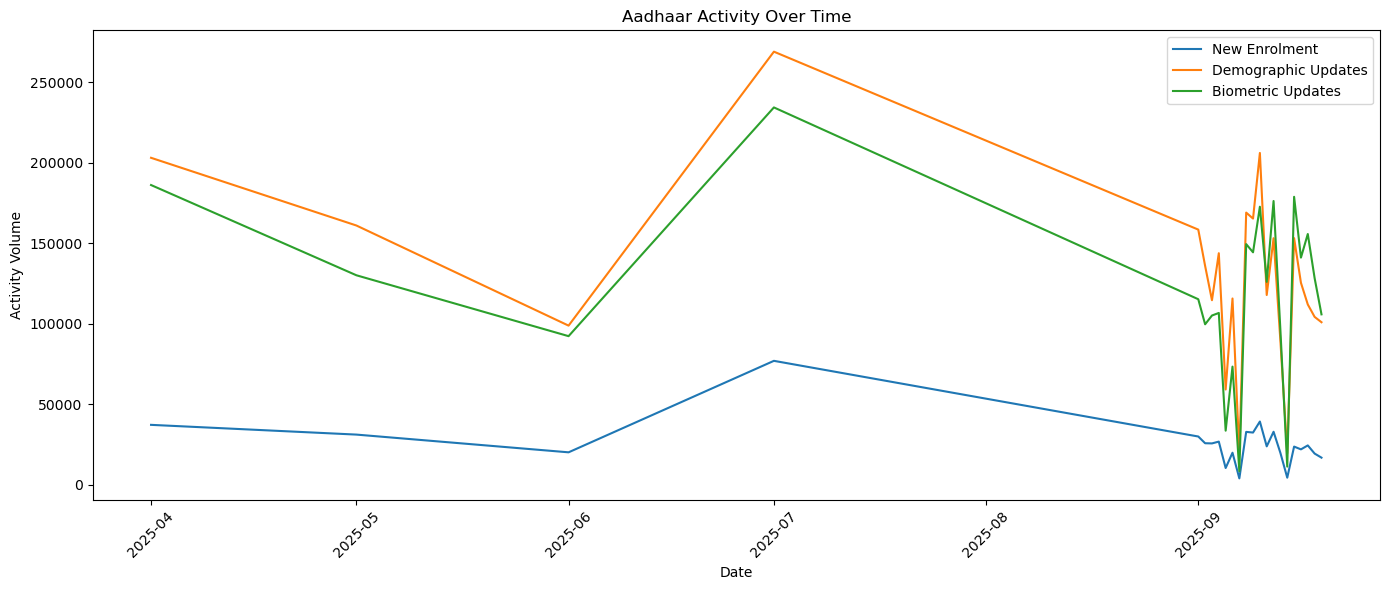

In [35]:
plt.figure(figsize=(14,6))

plt.plot(
    daily["date"],
    daily["enrolment"],
    label="New Enrolment"
)

plt.plot(
    daily["date"],
    daily["demographic"],
    label="Demographic Updates"
)

plt.plot(
    daily["date"],
    daily["biometric"],
    label="Biometric Updates"
)

plt.title("Aadhaar Activity Over Time")
plt.xlabel("Date")
plt.ylabel("Activity Volume")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Rolling Average -

In [43]:
daily["enrolment_7d"] = (
    daily["enrolment"]
    .rolling(7)
    .mean()
)

daily["demo_7d"] = (
    daily["demographic"]
    .rolling(7)
    .mean()
)

daily["bio_7d"] = (
    daily["biometric"]
    .rolling(7)
    .mean()
)

daily.head()

,date,enrolment,demographic,biometric,enrolment_7d,demo_7d,bio_7d
0,2025-04-01,37137,203085,186158,NaN,NaN,NaN
1,2025-05-01,31083,161012,130088,NaN,NaN,NaN
2,2025-06-01,20070,98798,92252,NaN,NaN,NaN
3,2025-07-01,76915,269033,234384,NaN,NaN,NaN
4,2025-09-01,29896,158462,115195,NaN,NaN,NaN


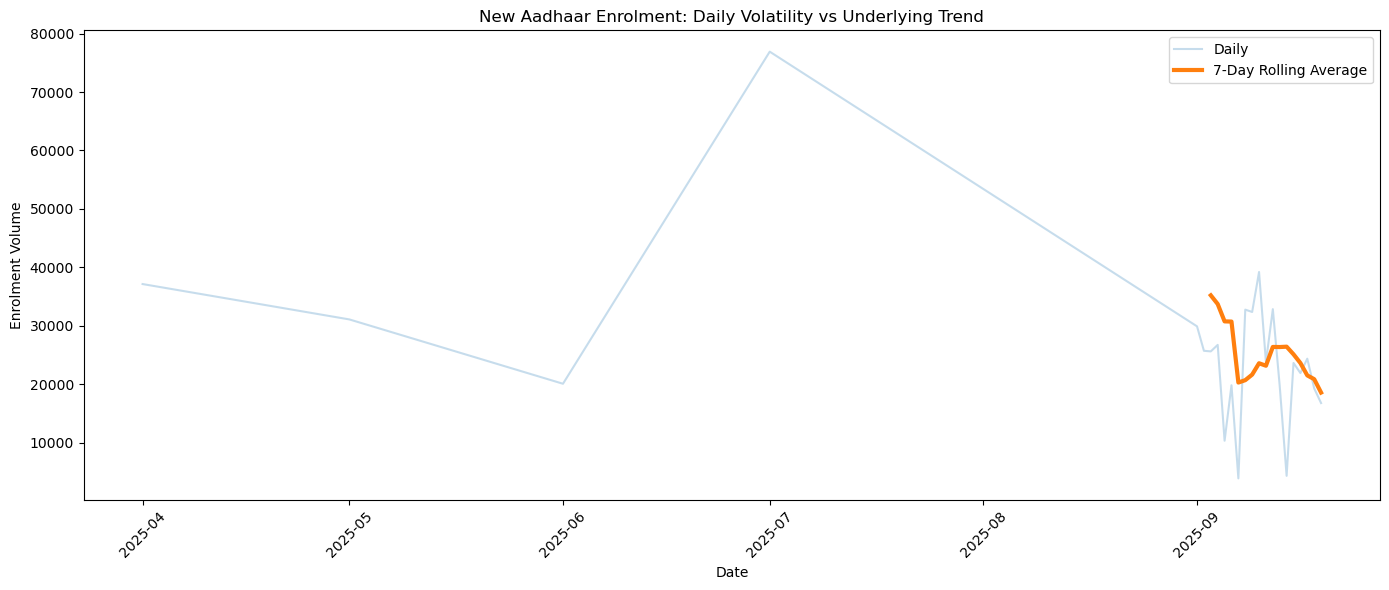

In [37]:
plt.figure(figsize=(14,6))

plt.plot(
    daily["date"],
    daily["enrolment"],
    alpha=0.25,
    label="Daily"
)

plt.plot(
    daily["date"],
    daily["enrolment_7d"],
    linewidth=3,
    label="7-Day Rolling Average"
)

plt.title("New Aadhaar Enrolment: Daily Volatility vs Underlying Trend")
plt.xlabel("Date")
plt.ylabel("Enrolment Volume")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3. State-level Petro Analysis -

#### $Question$ - Does a relatively small group of states/districts account for most enrolment activity?

In [39]:
state_summary = (
    df.groupby("state_clean")
      ["total_enrolment"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

state_summary["cumulative_pct"] = (
    state_summary["total_enrolment"].cumsum()
    / state_summary["total_enrolment"].sum()
    * 100
)
state_summary.head()

,state_clean,total_enrolment,cumulative_pct
0,Uttar Pradesh,119126,19.92
1,Madhya Pradesh,69389,31.52
2,Rajasthan,52741,40.34
3,Maharashtra,48533,48.46
4,Bihar,42907,55.63


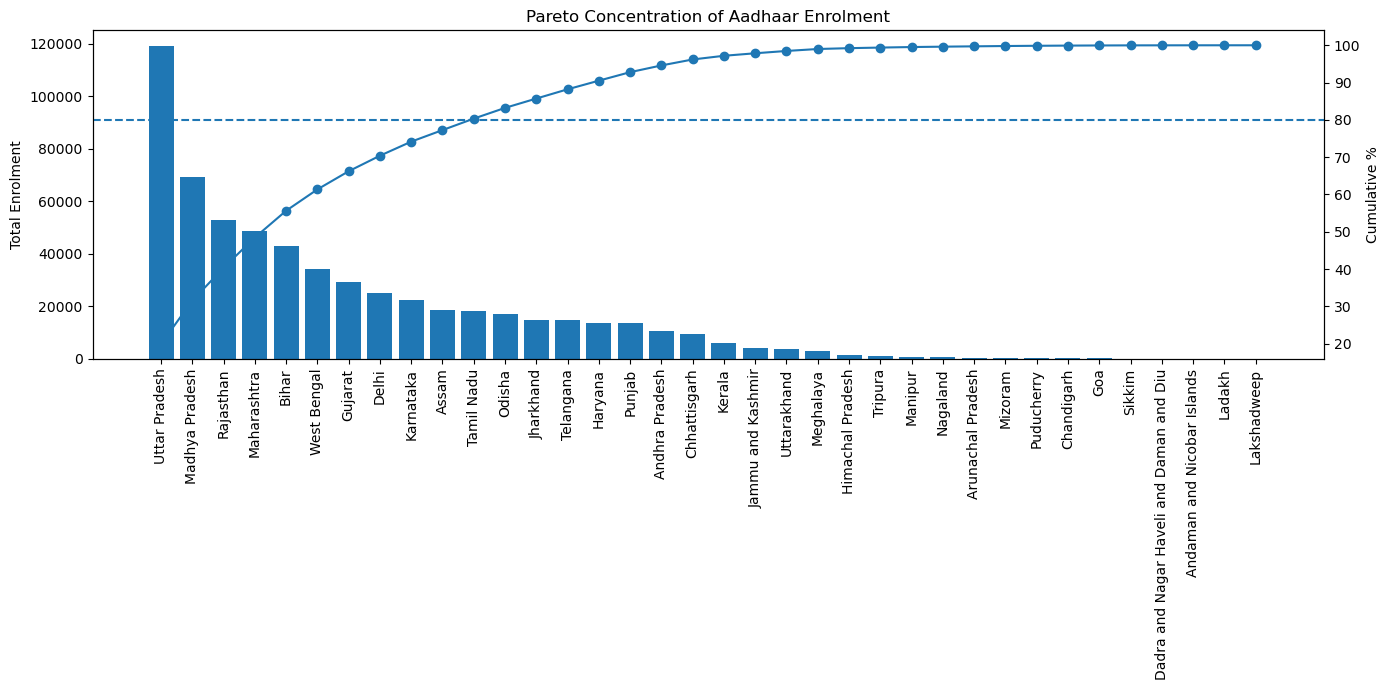

In [40]:
fig, ax1 = plt.subplots(figsize=(14,7))

ax1.bar(
    state_summary["state_clean"],
    state_summary["total_enrolment"]
)

ax1.set_ylabel("Total Enrolment")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    state_summary["state_clean"],
    state_summary["cumulative_pct"],
    marker="o"
)

ax2.axhline(80, linestyle="--")

ax2.set_ylabel("Cumulative %")

plt.title("Pareto Concentration of Aadhaar Enrolment")
plt.tight_layout()
plt.show()

### 4. Age-mix Analysis  -

#### $Asking$ - Are different states generating fundamentally different enrolment profiles?

In [41]:
age_state = (
    df.groupby("state_clean")
      .agg(
          age_0_5=("age_0_5", "sum"),
          age_5_17=("age_5_17", "sum"),
          age_18_plus=("age_18_greater", "sum")
      )
)

age_state["total"] = age_state.sum(axis=1)

age_pct = age_state[
    ["age_0_5", "age_5_17", "age_18_plus"]
].div(
    age_state["total"],
    axis=0
) * 100

age_state.head()

,age_0_5,age_5_17,age_18_plus,total
state_clean,,,,
Andaman and Nicobar Islands,42,3,0,45
Andhra Pradesh,9371,1344,71,10786
Arunachal Pradesh,285,249,0,534
Assam,13079,5023,417,18519
Bihar,18587,23975,345,42907


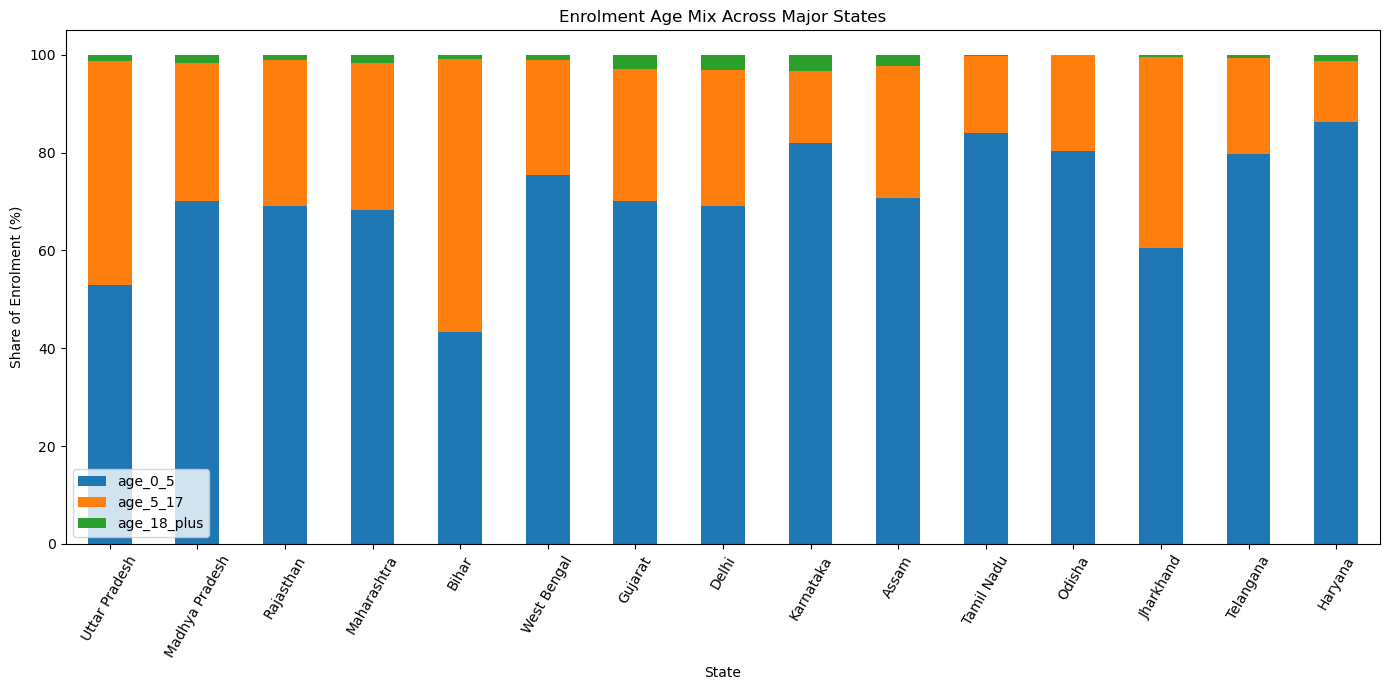

In [42]:
top_states = (
    age_state["total"]
    .sort_values(ascending=False)
    .head(15)
    .index
)

age_pct.loc[top_states].plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Enrolment Age Mix Across Major States")
plt.xlabel("State")
plt.ylabel("Share of Enrolment (%)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

### 5. Districts by New Enrolment Demand vs Maintenance Intensity -

In [46]:
district_summary = (
    df.groupby(
        ["state_clean", "district"]
    )
    .agg(
        enrolment=("total_enrolment", "sum"),
        demo_updates=("total_demo_updates", "sum"),
        bio_updates=("total_bio_updates", "sum"),
        child_enrolment=("age_0_5", "sum")
    )
    .reset_index()
)

district_summary["total_updates"] = (
    district_summary["demo_updates"]
    + district_summary["bio_updates"]
)

district_summary["maintenance_intensity"] = (
    district_summary["total_updates"]
    / district_summary["enrolment"].replace(0, np.nan)
)

district_summary["child_share"] = (
    district_summary["child_enrolment"]
    / district_summary["enrolment"].replace(0, np.nan)
)

district_summary.head()

,state_clean,district,enrolment,demo_updates,bio_updates,child_enrolment,total_updates,maintenance_intensity,child_share
0,Andaman and Nicobar Islands,Andamans,3,10,26,2,36,12.00,0.67
1,Andaman and Nicobar Islands,Nicobar,7,22,31,7,53,7.57,1.00
2,Andaman and Nicobar Islands,North And Middle Andaman,12,40,90,12,130,10.83,1.00
3,Andaman and Nicobar Islands,South Andaman,23,69,162,21,231,10.04,0.91
4,Andhra Pradesh,Adilabad,176,997,1470,139,2467,14.02,0.79


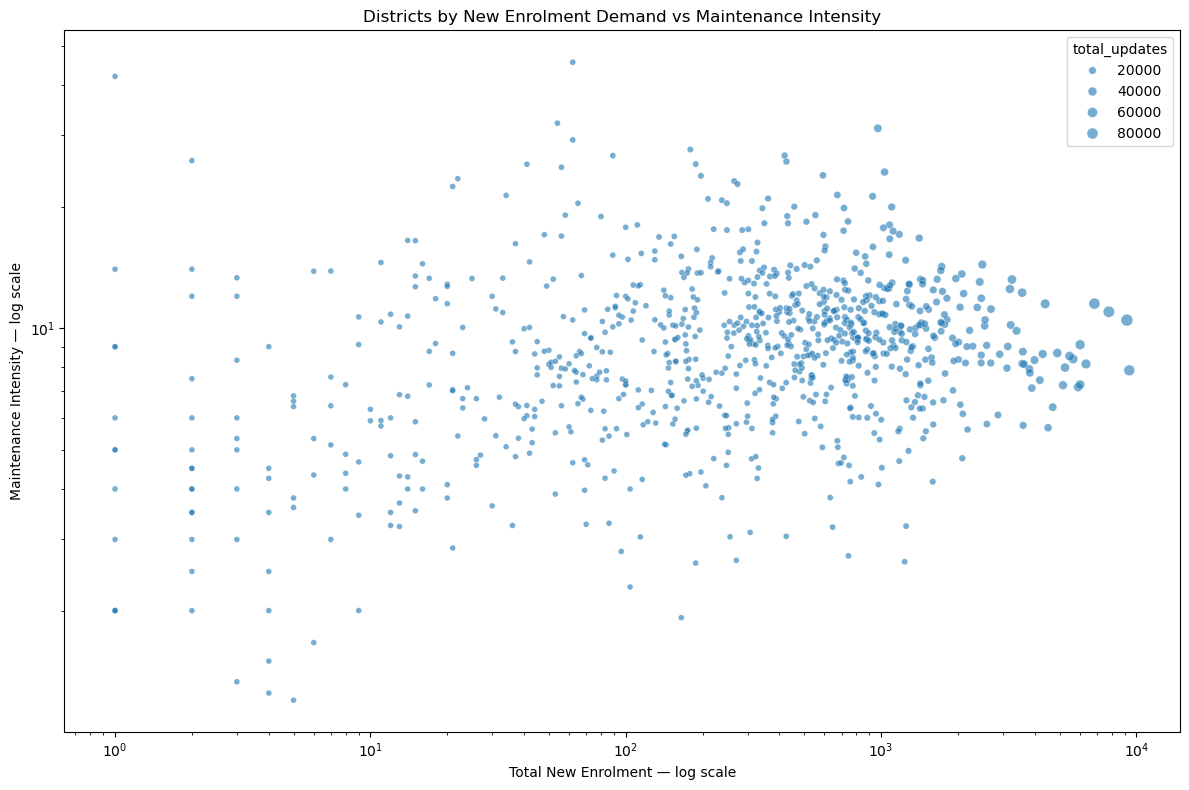

In [47]:
# Scatter Plot -
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=district_summary,
    x="enrolment",
    y="maintenance_intensity",
    size="total_updates",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Districts by New Enrolment Demand vs Maintenance Intensity"
)

plt.xlabel("Total New Enrolment — log scale")
plt.ylabel("Maintenance Intensity — log scale")

plt.tight_layout()
plt.show()

### 6. District Personas -

In [48]:
# Because raw volumes are highly skewed:

cluster_data = district_summary[
    [
        "enrolment",
        "maintenance_intensity",
        "child_share",
        "bio_updates"
    ]
].replace([np.inf, -np.inf], np.nan).dropna()

In [50]:
cluster_features = np.log1p(
    cluster_data[
        [
            "enrolment",
            "maintenance_intensity",
            "child_share",
            "bio_updates"
        ]
    ]
)

cluster_features.head()

,enrolment,maintenance_intensity,child_share,bio_updates
0,1.39,2.56,0.51,3.30
1,2.08,2.15,0.69,3.47
2,2.56,2.47,0.69,4.51
3,3.18,2.40,0.65,5.09
4,5.18,2.71,0.58,7.29


In [52]:
# Scale -
scaler = StandardScaler()

X = scaler.fit_transform(cluster_features)

# Test several cluster counts -

inertia = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X)

    inertia.append(model.inertia_)

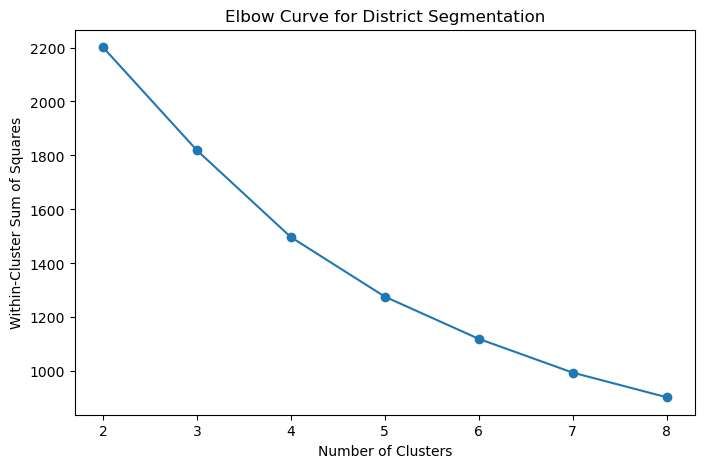

In [53]:
# Plot -
plt.figure(figsize=(8,5))

plt.plot(
    range(2,9),
    inertia,
    marker="o"
)

plt.title("Elbow Curve for District Segmentation")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum of Squares")

plt.show()

In [57]:
# 4 clusters based on the elbow and interpret them -
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

cluster_data["cluster"] = kmeans.fit_predict(X)

kmeans

,n_clusters,4
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


-----------------------------------------------------------------------------------------------------------------------------------

#### Interprating the Clusters -

In [58]:
cluster_profile = (
    cluster_data
    .groupby("cluster")
    .mean()
)

display(cluster_profile)

,enrolment,maintenance_intensity,child_share,bio_updates
cluster,,,,
0,30.95,6.92,0.81,74.83
1,398.53,9.73,0.82,"1,743.35"
2,"1,561.94",11.55,0.59,"7,477.60"
3,64.79,6.34,0.29,102.27


--------------------------------------------------------------------------------------------------------------------------------------

### Anomaly Detection -

In [60]:
# Create district-day activity -
df["district_day_activity"] = (
    df["total_enrolment"]
    + df["total_updates"]
)

# Then -
df["district_mean"] = (
    df.groupby(["state_clean", "district"])
      ["district_day_activity"]
      .transform("mean")
)

df["district_std"] = (
    df.groupby(["state_clean", "district"])
      ["district_day_activity"]
      .transform("std")
)

# Calculating z-score -
df["activity_zscore"] = (
    df["district_day_activity"]
    - df["district_mean"]
) / df["district_std"].replace(0, np.nan)

# Flagging it -
df["anomaly_flag"] = (
    df["activity_zscore"].abs() >= 3
)

# Finally -
anomalies = (
    df[df["anomaly_flag"]]
    .sort_values(
        "activity_zscore",
        key=lambda x: x.abs(),
        ascending=False
    )
)

display(
    anomalies[
        [
            "date",
            "state_clean",
            "district",
            "pincode",
            "district_day_activity",
            "activity_zscore"
        ]
    ].head(20)
)

,date,state_clean,district,pincode,district_day_activity,activity_zscore
223,2025-07-01,Maharashtra,Nashik,422003,6799,20.07
209,2025-07-01,Maharashtra,Pune,411048,4860,19.66
226,2025-07-01,Maharashtra,Pune,411028,4221,17.04
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,1133,16.87
85,2025-05-01,Gujarat,Ahmedabad,380026,5076,16.55
31,2025-04-01,Rajasthan,Ajmer,305001,6090,15.99
33,2025-04-01,Rajasthan,Nagaur,341001,5779,15.91
25,2025-04-01,Maharashtra,Aurangabad,431001,9601,15.49
167,2025-07-01,Uttar Pradesh,Kanpur Nagar,208001,12073,14.57
213,2025-07-01,Rajasthan,Jaipur,302012,9619,14.43


### Positive VS Negative Anomalies -

In [61]:
# Positive Anomalies -
positive_anomalies = df[
    df["activity_zscore"] >= 3
].sort_values(
    "activity_zscore",
    ascending=False
)

# Negative Anomalies -
negative_anomalies = df[
    df["activity_zscore"] <= -3
].sort_values(
    "activity_zscore"
)

In [62]:
positive_anomalies.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity,total_enrolment,total_demo_updates,total_bio_updates,total_updates,update_to_enrolment_ratio,child_share,bio_update_share,year,month,day,weekday,day_of_week,is_weekend,week,district_day_activity,district_mean,district_std,activity_zscore,anomaly_flag
223,2025-07-01,Maharashtra,Nashik,422003,475,261,13,261,1723,1409,2657,Maharashtra,422003,True,Valid,749,1984,4066,6050,8.08,0.63,0.67,2025,7,1,Tuesday,1,False,27,6799,102.69,333.61,20.07,True
209,2025-07-01,Maharashtra,Pune,411048,350,239,11,308,2082,739,1131,Maharashtra,411048,True,Valid,600,2390,1870,4260,7.10,0.58,0.44,2025,7,1,Tuesday,1,False,27,4860,67.62,243.77,19.66,True
226,2025-07-01,Maharashtra,Pune,411028,269,134,13,229,1869,744,963,Maharashtra,411028,True,Valid,416,2098,1707,3805,9.15,0.65,0.45,2025,7,1,Tuesday,1,False,27,4221,67.62,243.77,17.04,True
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,Tamil Nadu,600045,True,Valid,114,555,464,1019,8.94,0.71,0.46,2025,4,1,Tuesday,1,False,14,1133,36.68,65.01,16.87,True
85,2025-05-01,Gujarat,Ahmedabad,380026,121,47,12,292,1940,1044,1620,Gujarat,380026,True,Valid,180,2232,2664,4896,27.20,0.67,0.54,2025,5,1,Thursday,3,False,18,5076,80.76,301.81,16.55,True


In [64]:
negative_anomalies.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,state_clean,pincode_str,valid_pincode,pincode_validity,total_enrolment,total_demo_updates,total_bio_updates,total_updates,update_to_enrolment_ratio,child_share,bio_update_share,year,month,day,weekday,day_of_week,is_weekend,week,district_day_activity,district_mean,district_std,activity_zscore,anomaly_flag


### Now we have -
#### $Surge$ $events$ vs $Activity$ $collapses$

- **Surge events** - District suddenly much busier than normal.
- **Activity collapses** - District suddenly much quieter than normal

#### Vesulizing the Anomalies -

In [69]:
# Heatmap -
top_anomaly_districts = (
    positive_anomalies
    .groupby(["state_clean", "district"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)

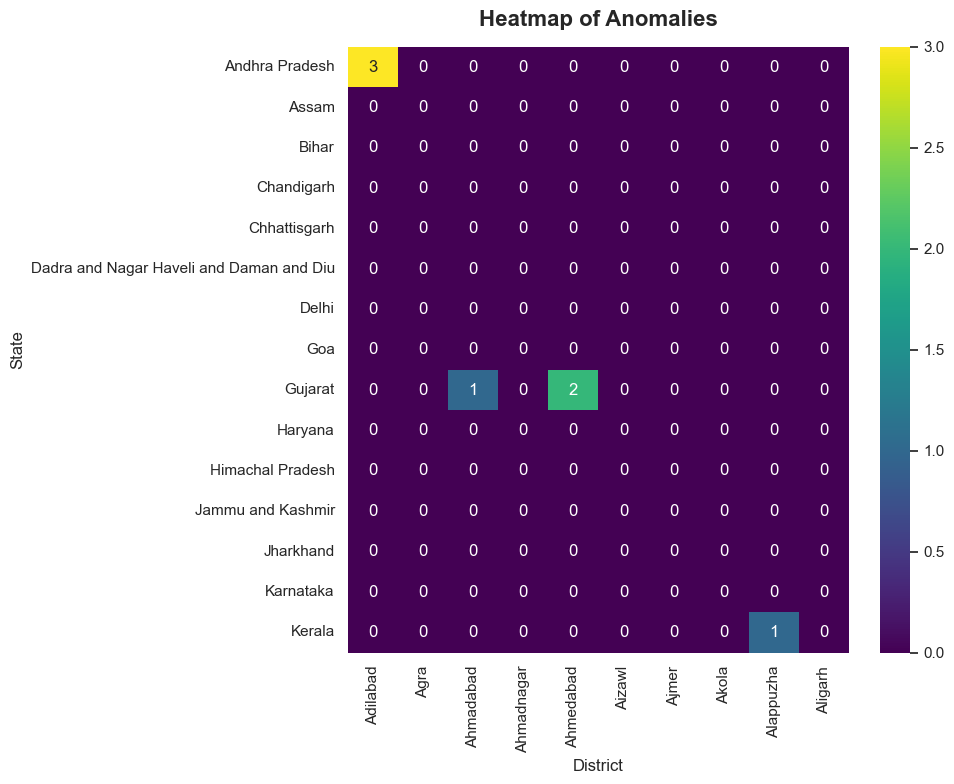

In [73]:
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

pivot_data = positive_anomalies.pivot_table(
    index="state_clean", columns="district", aggfunc="size", fill_value=0
)

sns.heatmap(pivot_data.iloc[:15, :10], cmap="viridis", annot=True, fmt="d")

plt.title("Heatmap of Anomalies", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("District", fontsize=12)
plt.ylabel("State", fontsize=12)

plt.tight_layout()
plt.show()

------------------------------------------------------------------------------------------------------------------------------

#### 8. Weekday Analysis -

In [77]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_summary = (
    df.groupby("weekday")["total_enrolment"]
      .mean()
      .reindex(weekday_order)
)
weekday_order

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

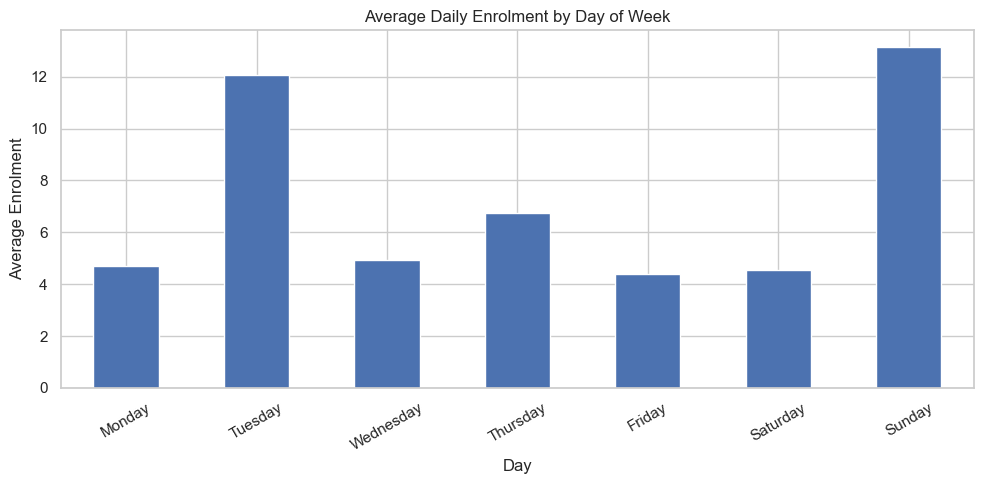

In [76]:
# Plot -
weekday_summary.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Daily Enrolment by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Enrolment")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 9. Demographic vs Biometric Updates -

<Figure size 1000x1000 with 0 Axes>

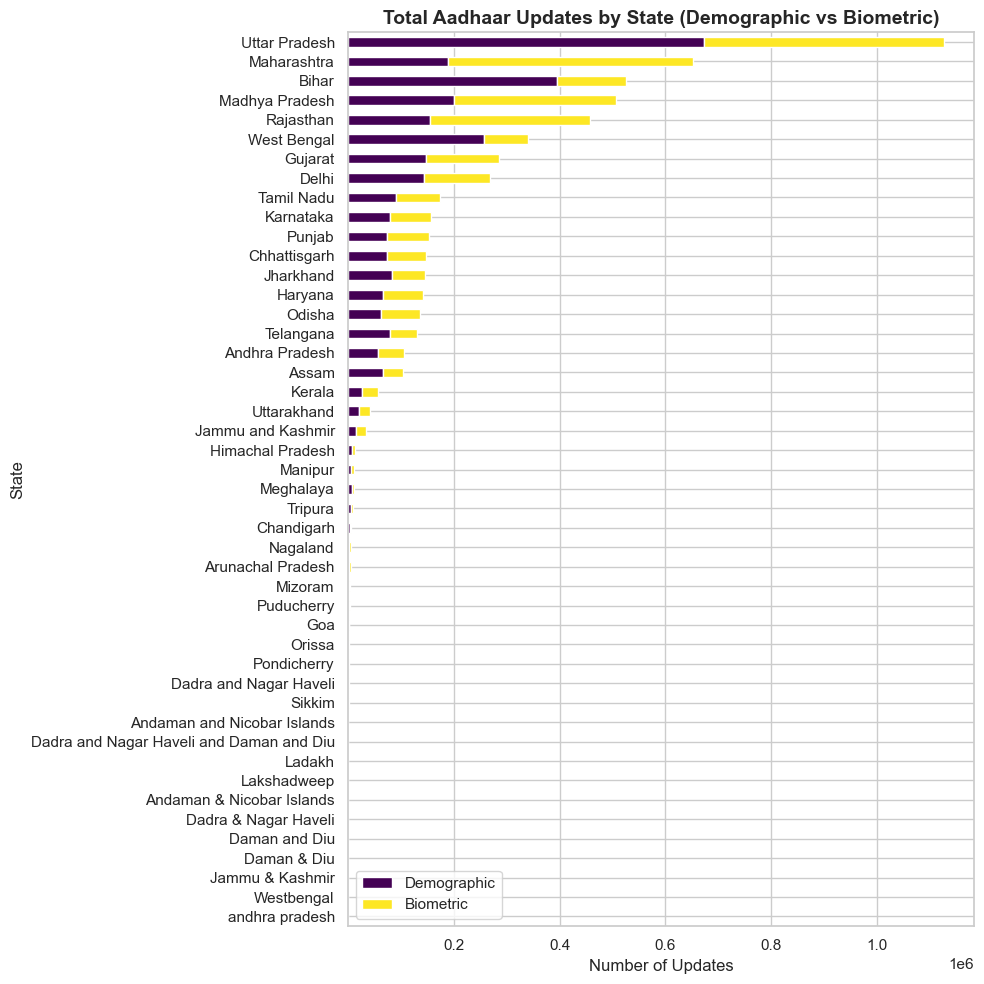

In [81]:
# Calculate total updates and sort
update_summary["total_updates"] = (
    update_summary["demographic"] + update_summary["biometric"]
)
update_summary_sorted = update_summary.sort_values(by="total_updates", ascending=True)

plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid")

# Plot stacked horizontal bars for demographic vs biometric
update_summary_sorted[["demographic", "biometric"]].plot(
    kind="barh", stacked=True, figsize=(10, 10), colormap="viridis"
)

plt.title(
    "Total Aadhaar Updates by State (Demographic vs Biometric)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of Updates", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.legend(["Demographic", "Biometric"])
plt.tight_layout()
plt.show()

### 10. District Anomaly Heatmap - 

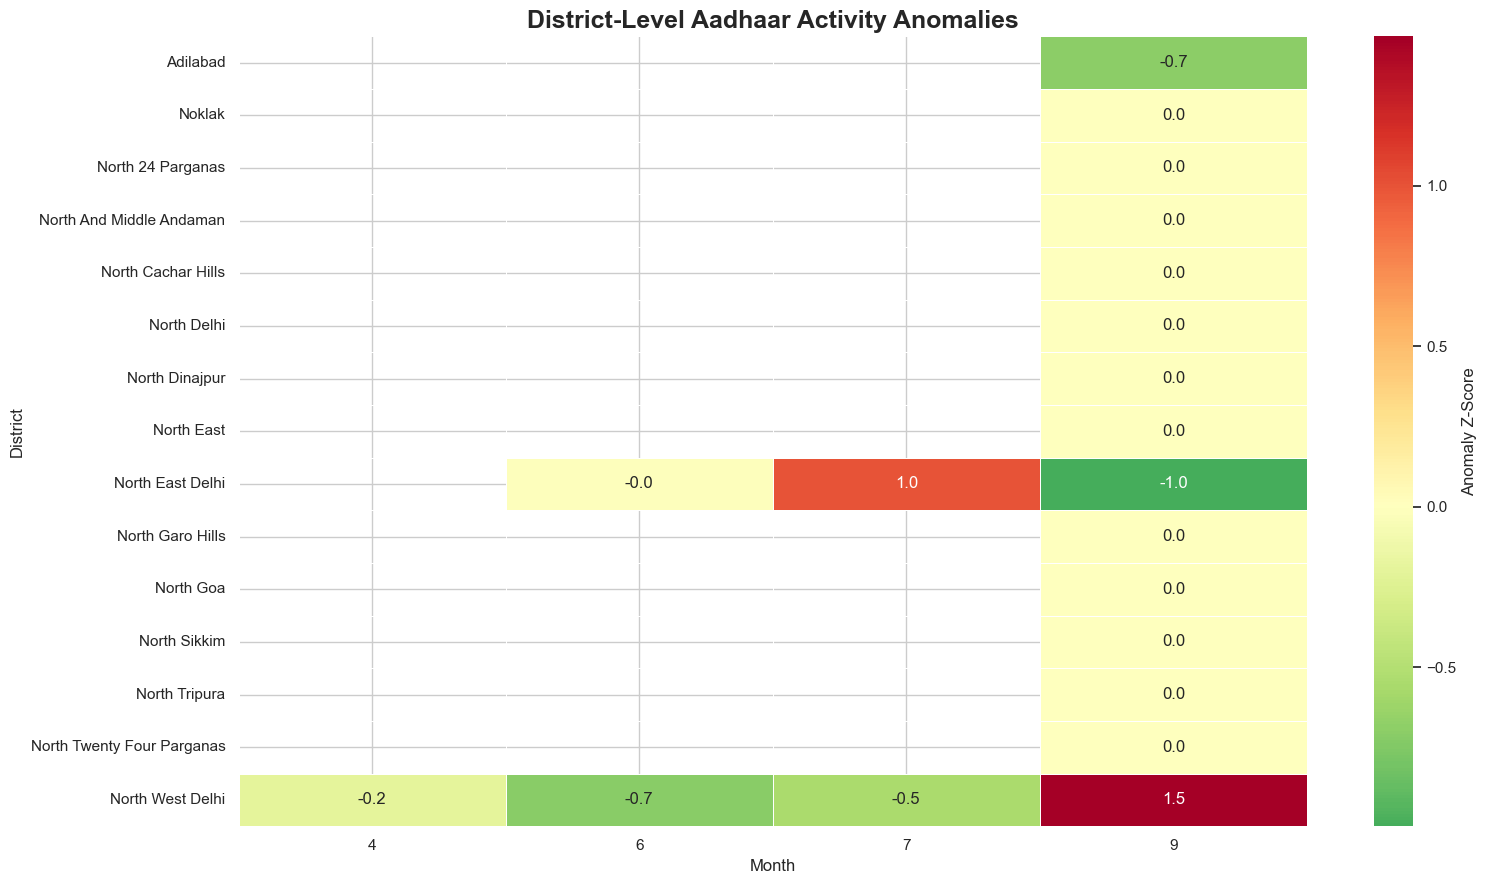

In [83]:
df["total_activity"] = (
    df["age_0_5"]
    + df["age_5_17"]
    + df["age_18_greater"]
    + df["demo_age_5_17"]
    + df["demo_age_17_"]
    + df["bio_age_5_17"]
    + df["bio_age_17_"]
)

district_month = (
    df.groupby(["district", "state", "month"], as_index=False)
      .agg(
          total_activity=("total_activity", "sum")
      )
)

def zscore(group):
    mean = group["total_activity"].mean()
    std = group["total_activity"].std()

    if std == 0 or pd.isna(std):
        group["z_score"] = 0
    else:
        group["z_score"] = (
            group["total_activity"] - mean
        ) / std

    return group

district_month = (
    district_month
    .groupby("district", group_keys=False)
    .apply(zscore)
    .reset_index(drop=True)
)

# Find districts with the most extreme anomalies
top_districts = (
    district_month
    .groupby(["district", "state"])["z_score"]
    .apply(lambda x: (abs(x) >= 2).sum())
    .sort_values(ascending=False)
    .head(15)
    .reset_index(name="anomaly_count")
)

# Keep only these districts
selected = district_month.merge(
    top_districts[["district", "state"]],
    on=["district", "state"],
    how="inner"
)

# Create heatmap
anomaly_heatmap = selected.pivot(
    index="district",
    columns="month",
    values="z_score"
)

plt.figure(figsize=(16, 9))

sns.heatmap(
    anomaly_heatmap,
    center=0,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={"label": "Anomaly Z-Score"}
)

plt.title(
    "District-Level Aadhaar Activity Anomalies",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("District")

plt.tight_layout()
plt.show()

### 11. Correlation Analysis -

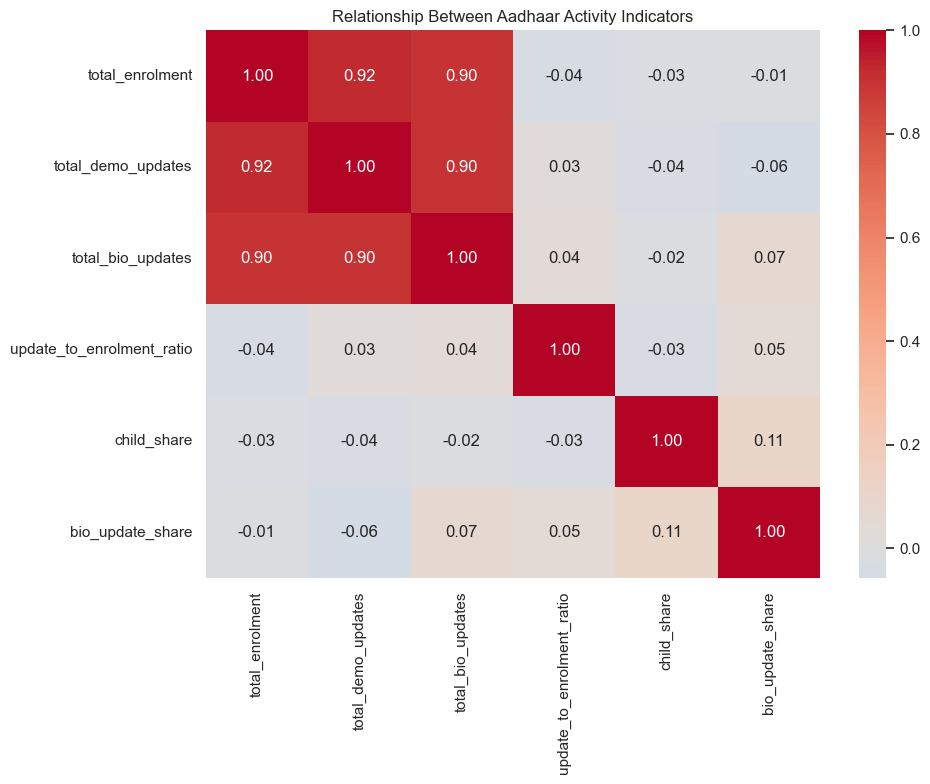

In [84]:
corr_cols = [
    "total_enrolment",
    "total_demo_updates",
    "total_bio_updates",
    "update_to_enrolment_ratio",
    "child_share",
    "bio_update_share"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Relationship Between Aadhaar Activity Indicators")

plt.tight_layout()
plt.show()

## Building the "$Aadhaar$ $Service$ $Pressure$ $Index$" -

In [85]:
# Create total aggregate columns before running the district summary groupby
df["total_enrolment"] = df["age_0_5"] + df["age_5_17"] + df["age_18_greater"]
df["total_updates"] = df["demo_age_5_17"] + df["demo_age_17_"] + df["bio_age_5_17"] + df["bio_age_17_"]
df["total_bio_updates"] = df["bio_age_5_17"] + df["bio_age_17_"]

# If you haven't defined anomaly_flag yet, initialize it or create the logic for it:
# df["anomaly_flag"] = ... 

# Creating district summary
district_features = (
    df.groupby(["state_clean", "district"])
    .agg(
        enrolment=("total_enrolment", "sum"),
        updates=("total_updates", "sum"),
        biometric=("total_bio_updates", "sum"),
        child_enrolment=("age_0_5", "sum"),
        anomaly_days=("anomaly_flag", "sum"),
    )
    .reset_index()
)

district_features["maintenance_intensity"] = district_features["updates"] / district_features["enrolment"].replace(0, np.nan)
district_features["bio_share"] = district_features["biometric"] / district_features["updates"].replace(0, np.nan)
district_features["child_share"] = district_features["child_enrolment"] / district_features["enrolment"].replace(0, np.nan)

# Scaling the features
score_cols = ["maintenance_intensity", "bio_share", "anomaly_days"]
score_data = district_features[score_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
scaled = StandardScaler().fit_transform(score_data)

district_features["service_pressure_score"] = scaled[:, 0] + scaled[:, 1] + scaled[:, 2]

# For the Rankings
pressure_ranking = district_features.sort_values("service_pressure_score", ascending=False)
display(pressure_ranking.head(20))

,state_clean,district,enrolment,updates,biometric,child_enrolment,anomaly_days,maintenance_intensity,bio_share,child_share,service_pressure_score
507,Maharashtra,Solapur,1115,19391,15261,748,9,17.39,0.79,0.67,7.28
883,West Bengal,North 24 Parganas,2914,25127,7259,2273,18,8.62,0.29,0.78,6.67
463,Maharashtra,Ahmadnagar,1100,21954,18119,704,6,19.96,0.83,0.64,6.60
485,Maharashtra,Kolhapur,716,14207,11378,569,6,19.84,0.80,0.79,6.43
505,Maharashtra,Satara,426,11018,8932,352,3,25.86,0.81,0.83,6.32
465,Maharashtra,Akola,457,9140,7647,389,5,20.00,0.84,0.85,6.20
522,Manipur,Thoubal,62,2824,819,32,0,45.55,0.29,0.52,5.86
504,Maharashtra,Sangli,742,13638,11343,502,5,18.38,0.83,0.68,5.82
503,Maharashtra,Ratnagiri,266,6153,4949,229,3,23.13,0.80,0.86,5.69
472,Maharashtra,Buldhana,674,14405,12315,523,3,21.37,0.85,0.78,5.63


---------------------------------------------------------------------------------------------------------------------------------

## Creating three operational categories -

In [91]:
# Create a summary dataframe showing your counts alongside the framework's meaning
framework_summary = (
    district_features["district_behaviour"]
    .value_counts()
    .reset_index(name="district_count")
)

# Map the interpretations and actions matching your reference framework
interpretation_map = {
    "High enrolment + low maintenance": {
        "Interpretation": "New-ID demand",
        "Possible action": "Enrolment capacity",
    },
    "Low enrolment + high maintenance": {
        "Interpretation": "Mature/update-heavy",
        "Possible action": "Update capacity",
    },
    "High enrolment + high maintenance": {
        "Interpretation": "High operational pressure",
        "Possible action": "Dual capacity",
    },
    "Low enrolment + low activity": {
        "Interpretation": "Low activity",
        "Possible action": "Investigate accessibility/data coverage",
    },
}

framework_summary["Interpretation"] = framework_summary["district_behaviour"].map(
    lambda x: interpretation_map.get(x, {}).get("Interpretation")
)
framework_summary["Possible action"] = framework_summary["district_behaviour"].map(
    lambda x: interpretation_map.get(x, {}).get("Possible action")
)

# Rename column for display
framework_summary = framework_summary.rename(
    columns={"district_behaviour": "District behaviour"}
)

display(framework_summary)

,District behaviour,district_count,Interpretation,Possible action
0,Low enrolment + low activity,265,Low activity,Investigate accessibility/data coverage
1,High enrolment + high maintenance,264,High operational pressure,Dual capacity
2,Low enrolment + high maintenance,184,Mature/update-heavy,Update capacity
3,High enrolment + low maintenance,184,New-ID demand,Enrolment capacity


-------------------------------------------------------------------------------------------------------------------------------------

## The Final Story Could Be -

### "Uttar Pradesh has the highest enrolment."

- **Instead**:

>"Aadhaar activity is not uniform: districts differ not only in the volume of new enrolment but also in the intensity and composition of ongoing maintenance activity."

- **Then**:

>"When activity is normalised against each district's own baseline, several districts emerge as operational anomalies that would be invisible in a simple state-level ranking."

- **Then**:

>"We therefore propose an EDA-based district segmentation framework that distinguishes enrolment-led, maintenance-led, high-pressure and low-activity geographies."

-----------------------------------------------------------------------------------------------------------------------------------------

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

-----------------------------------------------------------------------------------------------------------------------------------------